# Downstream beam prediction (RQ3)

**Run order:** `tuning.ipynb` → `imputation.ipynb` → `downstream.ipynb`

Feeds the imputed training data into a scenario-specific beam predictor (GPS → beam index, implemented as a small MLP) and reports Top-1 through Top-5 accuracy against a clean-data ceiling.

For each `(mechanism, proportion, method)` cell, training rows are imputed in-fold and the test set always uses clean data, so imputation quality is the only variable. Splits respect sequence boundaries (GroupKFold for scenarios with ≤ 40 sequences, GroupShuffleSplit otherwise) to prevent data leakage across the temporal grouping.

Results are written to `results/csv/{dataset}_downstream_grouped.csv`.

**To switch datasets:** change `DATASET` in Cell 1 to `"scenario5"` or `"scenario33"` and re-run.

## 1. Path setup + dataset

In [12]:
# ---------------------------------------------------------------------------
# Path setup + dataset switch. This is the ONLY cell you change between
# datasets: set DATASET to a key registered in common.datasets.
# ---------------------------------------------------------------------------
import sys
from pathlib import Path

DATASET = "scenario5"          # "scenario5" | "scenario33"


def _find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "data").is_dir():
            return parent
    return start.parent


REPO_ROOT   = _find_repo_root(Path.cwd())
SRC         = REPO_ROOT / "src"
RESULTS_DIR = REPO_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
CSV_DIR     = RESULTS_DIR / "csv"
TUNED_PARAMS_PATH = RESULTS_DIR / "tuned_params.json"
for _d in (FIGURES_DIR, CSV_DIR):
    _d.mkdir(parents=True, exist_ok=True)

_diffputer = REPO_ROOT / "external" / "DiffPuter"
for _p in (REPO_ROOT, SRC,
           _diffputer / "baselines" / "GRAPE",
           _diffputer / "baselines",
           _diffputer):
    _sp = str(_p.resolve())
    if _p.exists() and _sp not in sys.path:
        sys.path.insert(0, _sp)

from common.datasets import get_dataset

spec = get_dataset(DATASET)
DATA_DIR = REPO_ROOT / "data" / spec.data_dirname
clean_data = spec.loader(DATA_DIR)
print(f"Dataset: {spec.name}  |  clean_data {tuple(clean_data.shape)}")

print("DATA_DIR:", DATA_DIR)

Parsing location files...
Parsing mmWave power files...
Argmax matches unit1_beam_index: 100.00%
Parsed shape: (2300, 71)  |  missing cells: 0
Dropped 0 incomplete row(s) (2300 -> 2300); experiments require fully observed input.
Clean data shape: (2300, 71)
Dataset: scenario5  |  clean_data (2300, 71)
DATA_DIR: /mnt/c/Users/Kenneth Chan/Documents/School/Research Project/Repo/ImputationFor6GDatasets/data/Scenario5


## 2. Clean data + the aligned group column

The sequence group column (`spec.group_col`) is read from the loaded frame and kept row-aligned with `clean_data` throughout. It is used only for splitting (GroupKFold / GroupShuffleSplit) and is never included in the feature matrix or passed to an imputer.

In [13]:
import numpy as np
import pandas as pd

seq_groups = clean_data[spec.group_col].to_numpy()

n_sequences = len(np.unique(seq_groups))
_counts = pd.Series(seq_groups).value_counts()
print(f"Rows: {len(clean_data)}  |  distinct sequences: {n_sequences}")
print(f"Rows per sequence (min/median/max): "
      f"{_counts.min()} / {int(_counts.median())} / {_counts.max()}")

Rows: 2300  |  distinct sequences: 29
Rows per sequence (min/median/max): 49 / 76 / 127


## 3. Feature matrix + index maps

Scales GPS features with MinMaxScaler (beam power columns are left in their original scale). `beam_idx` and `gps_idx` are integer index arrays derived from `spec`; all downstream functions receive these indices rather than column names so the logic is dataset-agnostic. The leakage guard in §7 asserts that `build_mask` never touches GPS columns.

In [14]:
from sklearn.preprocessing import MinMaxScaler

BEAM_COLS           = spec.target_cols
RETAINED_COLS       = spec.retained_cols
DOWNSTREAM_GPS_COLS = spec.downstream_feature_cols

clean_df = (clean_data[RETAINED_COLS].copy()
            if isinstance(clean_data, pd.DataFrame)
            else pd.DataFrame(clean_data, columns=RETAINED_COLS))

scaler = MinMaxScaler()
clean_df[DOWNSTREAM_GPS_COLS] = scaler.fit_transform(
    clean_df[DOWNSTREAM_GPS_COLS].astype(float))

data_scaled = clean_df.to_numpy(dtype=float)

beam_idx = np.array([RETAINED_COLS.index(c) for c in BEAM_COLS])
gps_idx  = np.array([RETAINED_COLS.index(c) for c in DOWNSTREAM_GPS_COLS])

assert set(gps_idx.tolist()).isdisjoint(set(beam_idx.tolist())), (
    "LEAKAGE: gps_idx and beam_idx overlap — predictor features include "
    "label-source columns."
)
print("data_scaled:", data_scaled.shape)
print("beam_idx:", beam_idx.min(), "..", beam_idx.max(), "| gps_idx:", gps_idx.tolist())
print("Leakage guard passed: GPS features disjoint from beam label-source.")

data_scaled: (2300, 70)
beam_idx: 0 .. 63 | gps_idx: [64, 65]
Leakage guard passed: GPS features disjoint from beam label-source.


## 4. Beam predictor (MLP) and Top-K metric

A lightweight fully-connected network (GPS → beam class) trained from scratch inside each cross-validation fold. Architecture and training budget are fixed across all methods and datasets so that imputation quality — not predictor capacity — drives accuracy differences. `predict_topk_mlp` is defined here rather than in `src/` because it is intentionally local to this evaluation context.

In [15]:
import torch
import torch.nn as nn


def predict_topk_mlp(gps_train, labels_train, gps_test,
                     n_classes=64, hidden=256, n_layers=3,
                     epochs=60, lr=1e-2, batch_size=32,
                     val_frac=0.25, seed=0, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    torch.manual_seed(seed)
    np.random.seed(seed)

    y = labels_train.astype(int) - 1

    n = len(gps_train)
    perm = np.random.default_rng(seed).permutation(n)
    n_val = max(1, int(round(val_frac * n)))
    val_i, tr_i = perm[:n_val], perm[n_val:]

    Xtr = torch.tensor(gps_train[tr_i], dtype=torch.float32, device=device)
    ytr = torch.tensor(y[tr_i],         dtype=torch.long,    device=device)
    Xva = torch.tensor(gps_train[val_i], dtype=torch.float32, device=device)
    yva = torch.tensor(y[val_i],         dtype=torch.long,    device=device)
    Xte = torch.tensor(gps_test,         dtype=torch.float32, device=device)

    layers, in_dim = [], gps_train.shape[1]
    for _ in range(n_layers):
        layers += [nn.Linear(in_dim, hidden), nn.ReLU()]
        in_dim = hidden
    layers += [nn.Linear(in_dim, n_classes)]
    model = nn.Sequential(*layers).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[20, 40], gamma=0.2)
    loss_fn = nn.CrossEntropyLoss()

    best_state, best_val_acc = None, -1.0
    idx = np.arange(len(tr_i))
    for epoch in range(epochs):
        model.train()
        np.random.shuffle(idx)
        for s in range(0, len(idx), batch_size):
            b = idx[s:s + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(Xtr[b]), ytr[b])
            loss.backward()
            opt.step()
        sched.step()

        model.eval()
        with torch.no_grad():
            val_acc = (model(Xva).argmax(1) == yva).float().mean().item()
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        logits = model(Xte).cpu().numpy()

    ranked_idx = np.argsort(-logits, axis=1)
    return ranked_idx + 1


def topk_accuracy(ranked_labels, true_labels, top_k=(1, 2, 3, 4, 5)):
    out = {}
    for k in top_k:
        in_topk = np.any(ranked_labels[:, :k] == true_labels[:, None], axis=1)
        out[f"top{k}_acc"] = float(in_topk.mean())
    return out

## 5. Downstream evaluation helpers

`downstream_eval` runs one `(mask, imputer, fold)` triple: applies the mask to the training split, calls the imputer, trains the MLP on the imputed training features, and evaluates on the clean test split. Passing `train_imputed` directly avoids redundant re-fitting when a pre-computed imputation is available. `_fill_residual_nans` is a belt-and-braces guard: any NaNs an imputer leaves behind are filled with column means so the predictor never receives NaN inputs.

In [16]:
def _fill_residual_nans(imputed, reference_masked):
    """Belt-and-braces: if an imputer leaves NaNs, fill with column means."""
    if np.isnan(imputed).any():
        col_means = np.nanmean(reference_masked, axis=0)
        col_means = np.where(np.isnan(col_means), 0.0, col_means)
        nan_pos = np.isnan(imputed)
        imputed[nan_pos] = np.take(col_means, np.where(nan_pos)[1])
    return imputed


def downstream_eval(data_scaled, beam_idx, gps_idx, mask, imputer,
                    seed, train_idx, test_idx, train_imputed=None, n_classes=64):
    if imputer is None:
        train_beams = data_scaled[train_idx][:, beam_idx]
    elif train_imputed is not None:
        assert len(train_imputed) == len(train_idx), (
            f"train_imputed has {len(train_imputed)} rows but train_idx has "
            f"{len(train_idx)} -- it must be train-rows-only, in train_idx order."
        )
        train_beams = train_imputed[:, beam_idx]
    else:
        data_train_masked = data_scaled[train_idx].copy()
        data_train_masked[mask[train_idx]] = np.nan
        data_train_imputed = imputer.fit_transform(data_train_masked, seed=seed)
        data_train_imputed = _fill_residual_nans(data_train_imputed, data_train_masked)
        train_beams = data_train_imputed[:, beam_idx]

    test_beams_clean = data_scaled[test_idx][:, beam_idx]
    labels_train = np.argmax(train_beams,      axis=1) + 1
    labels_test  = np.argmax(test_beams_clean, axis=1) + 1

    gps_train = data_scaled[train_idx][:, gps_idx]
    gps_test  = data_scaled[test_idx][:,  gps_idx]

    ranked = predict_topk_mlp(gps_train, labels_train, gps_test,
                              n_classes=n_classes, seed=seed)
    return topk_accuracy(ranked, labels_test, top_k=(1, 2, 3, 4, 5))

## 6. Sequence-aware splitter

`grouped_splits` selects between GroupKFold and GroupShuffleSplit based on the number of distinct sequences in the dataset. The threshold (40 sequences) ensures GroupKFold is used when the sequence count is small enough to make k-fold meaningful (Scenario 5: 29 sequences → GroupKFold; Scenario 33: 21 sequences → GroupKFold). In both cases the split asserts that no sequence appears in both train and test.

In [17]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

FEW_SEQ_THRESHOLD = 40


def grouped_splits(groups, seed, n_folds=3, test_size=0.2):
    n_rows = len(groups)
    n_seq = len(np.unique(groups))
    all_idx = np.arange(n_rows)

    if n_folds == 1 or n_seq < 2:
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        tr, te = next(gss.split(all_idx, groups=groups))
        assert set(groups[tr]).isdisjoint(set(groups[te]))
        yield tr, te
        return

    if n_seq <= FEW_SEQ_THRESHOLD:
        k = min(n_folds, n_seq)
        gkf = GroupKFold(n_splits=k)
        for tr, te in gkf.split(all_idx, groups=groups):
            assert set(groups[tr]).isdisjoint(set(groups[te]))
            yield tr, te
    else:
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        tr, te = next(gss.split(all_idx, groups=groups))
        assert set(groups[tr]).isdisjoint(set(groups[te]))
        yield tr, te


print(f"Splitter: {'GroupKFold' if n_sequences <= FEW_SEQ_THRESHOLD else 'GroupShuffleSplit'} "
      f"({n_sequences} sequences).")

Splitter: GroupKFold (29 sequences).


## 7. Mask sanity-check

Verifies two invariants before the full grid: (1) the realised beam-column missingness rate matches the requested rate within tolerance, and (2) GPS (predictor) columns are never touched by the mask. Failing either assertion indicates a misconfigured `ExperimentConfig` or `build_mask` call.

In [18]:
from common.amputation import build_mask

mar_driver_idx = [RETAINED_COLS.index(c) for c in spec.mar_driver_cols]

_rng = np.random.default_rng(0)
_m = build_mask("MCAR", data_scaled, 0.10, beam_idx, _rng,
                driver_col_idx=mar_driver_idx, mar_score_mode=spec.mar_score_mode)
print("Realised beam missingness:", round(float(_m[:, beam_idx].mean()), 4), "(target 0.10)")
assert not _m[:, gps_idx].any(), "GPS columns were amputed — build_mask not restricted to beams."
print("GPS columns untouched by mask: OK")

Realised beam missingness: 0.1012 (target 0.10)
GPS columns untouched by mask: OK


## 8. Run: clean baseline vs imputers

Executes the full `(mechanism × proportion × method × fold × seed)` grid. The clean baseline (`imputer=None`) trains on fully observed data and sets the performance ceiling. Cheap methods run 3 folds; DiffPuter and GRAPE run 1 fold due to compute cost — this asymmetry is a conceded limitation. Results accumulate in `results` and are written to CSV after the loop.

In [19]:
import time
from imputers.imputers import (
    MeanImputer, KNNImputerWrapper, SoftImputeWrapper, MICEImputer,
    HyperImputeImputer,
)
from imputers.diffputer_imputer import DiffPuterImputer
from imputers.grape_imputer import GRAPEImputer
from common.tuning import load_tuned_params

# ---------------------------------------------------------------------------
# Tuned hyperparameters — same frozen pipeline as the reconstruction notebook.
# ---------------------------------------------------------------------------
tp = load_tuned_params(TUNED_PARAMS_PATH, spec.name)
assert tp, (f"No tuned params for '{spec.name}' in {TUNED_PARAMS_PATH}. "
            f"Run tuning.ipynb with DATASET='{spec.name}' first.")
for _k in ("knn_n_neighbors", "softimpute_shrinkage", "diffputer",
           "grape_epochs", "grape_node_edge_dim", "grape_lr"):
    assert _k in tp, f"tuned_params.json missing key '{_k}' for {spec.name}."
print("Loaded tuned params:",
      {k: ("{...}" if isinstance(v, dict) else v) for k, v in tp.items()})

# Tuple: (label, imputer, mechanisms, proportions, n_folds)
FULL_MECH = ["MCAR", "MAR", "MNAR", "MCAR-Row"]
FULL_PROP = [0.10, 0.30, 0.50]

IMPUTERS = [
    ("mean",        MeanImputer(),                                                 FULL_MECH, FULL_PROP, 3),
    ("knn",         KNNImputerWrapper(k=tp["knn_n_neighbors"]),                    FULL_MECH, FULL_PROP, 3),
    ("softimpute",  SoftImputeWrapper(shrinkage_value=tp["softimpute_shrinkage"]), FULL_MECH, FULL_PROP, 3),
    ("mice",        MICEImputer(),                                                 FULL_MECH, FULL_PROP, 1),
    ("hyperimpute", HyperImputeImputer(),                                          FULL_MECH, FULL_PROP, 1),
    ("diffputer",   DiffPuterImputer(**tp["diffputer"]),                           FULL_MECH, FULL_PROP, 1),
    ("grape",       GRAPEImputer(epochs=tp["grape_epochs"],
                                 node_dim=tp["grape_node_edge_dim"],
                                 edge_dim=tp["grape_node_edge_dim"],
                                 lr=tp["grape_lr"]),                               FULL_MECH, FULL_PROP, 1),
]

SEEDS = (0, 1, 2)
CLEAN_FOLDS = 3
N_CLASSES = spec.n_classes

DOWNSTREAM_PATH = CSV_DIR / f"{spec.name}_downstream_full_results.csv"
CACHE_DIR = RESULTS_DIR / spec.name / "imputed_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _cache_path(method, mech, prop, seed, fold):
    # fold IS part of the key: each fold imputes its own train rows, so the
    # cached artifact is a per-fold TRAIN-ONLY imputation.
    return CACHE_DIR / f"{method}__{mech}__p{int(round(prop * 100)):02d}__s{seed}__f{fold}.npy"


def get_train_imputation(imputer, method, mech, prop, mask, seed, train_idx, fold):
    cpath = _cache_path(method, mech, prop, seed, fold)
    if cpath.exists():
        cached = np.load(cpath)
        if cached.shape[0] == len(train_idx):
            return cached
        cpath.unlink(missing_ok=True)
    data_train_masked = data_scaled[train_idx].copy()
    data_train_masked[mask[train_idx]] = np.nan
    t0 = time.time()
    imputed = imputer.fit_transform(data_train_masked, seed=seed)
    imputed = _fill_residual_nans(imputed, data_train_masked)
    np.save(cpath, imputed)
    print(f"  [cache] imputed {method} {mech} p={prop} s={seed} f{fold} "
          f"in {time.time() - t0:.1f}s -> {cpath.name}")
    return imputed


def _agg(cell_runs, base_row):
    row = dict(base_row)
    acc_keys = [k for k in cell_runs[0] if k.endswith("_acc")]
    row["n_runs"] = len(cell_runs)
    for k in acc_keys:
        vals = [r[k] for r in cell_runs]
        row[k] = float(np.mean(vals))
        row[f"{k}_std"] = float(np.std(vals))
    return row


# Resume checkpoint (granularity: mechanism x proportion x method).
if DOWNSTREAM_PATH.exists():
    done_df = pd.read_csv(DOWNSTREAM_PATH)
    done_keys = set(zip(done_df["mechanism"], done_df["proportion"], done_df["method"]))
    records = done_df.to_dict("records")
    print(f"Resuming: {len(done_keys)} result cells already in {DOWNSTREAM_PATH.name}.")
else:
    done_keys, records = set(), []


def _append_downstream(row):
    pd.DataFrame([row]).to_csv(
        DOWNSTREAM_PATH, mode="a", header=not DOWNSTREAM_PATH.exists(), index=False
    )


# ---------------------------------------------------------------------------
# CLEAN baseline: mask-independent, repeated over seeds, broadcast to every cell.
# ---------------------------------------------------------------------------
clean_needed = [(m, p) for m in FULL_MECH for p in FULL_PROP
                if (m, p, "clean") not in done_keys]

if clean_needed:
    t0 = time.time()
    clean_runs = []
    for seed in SEEDS:
        for tr, te in grouped_splits(seq_groups, seed=seed, n_folds=CLEAN_FOLDS):
            clean_runs.append(downstream_eval(
                data_scaled, beam_idx, gps_idx, mask=None, imputer=None,
                seed=seed, train_idx=tr, test_idx=te, train_imputed=None,
                n_classes=N_CLASSES,
            ))
    clean_stats = _agg(clean_runs, {"cached": False, "secs": round(time.time() - t0, 1)})
    for mech, prop in clean_needed:
        row = {"mechanism": mech, "proportion": prop, "method": "clean",
               "n_folds": CLEAN_FOLDS, **clean_stats}
        records.append(row)
        done_keys.add((mech, prop, "clean"))
        _append_downstream(row)
    print(f"clean (over {len(SEEDS)} seeds, {clean_stats['n_runs']} runs, "
          f"{clean_stats['secs']}s) broadcast to {len(clean_needed)} cells: "
          f"top1={clean_stats['top1_acc']:.3f} top5={clean_stats['top5_acc']:.3f}")


# ---------------------------------------------------------------------------
# Imputers: the mask matters, so loop mechanism x proportion x seed.
# ---------------------------------------------------------------------------
for label, imp, mechs, props, n_folds in IMPUTERS:
    for mech in mechs:
        for prop in props:
            key = (mech, prop, label)
            if key in done_keys:
                continue

            t0 = time.time()
            cell_runs = []
            for seed in SEEDS:
                rng = np.random.default_rng(seed)
                mask = build_mask(mech, data_scaled, prop, beam_idx, rng,
                                  driver_col_idx=mar_driver_idx,
                                  mar_score_mode=spec.mar_score_mode)

                for fold, (tr, te) in enumerate(
                        grouped_splits(seq_groups, seed=seed, n_folds=n_folds)):
                    train_imputed = None
                    if imp is not None:
                        train_imputed = get_train_imputation(
                            imp, label, mech, prop, mask, seed, tr, fold)
                    cell_runs.append(downstream_eval(
                        data_scaled, beam_idx, gps_idx, mask, imp,
                        seed=seed, train_idx=tr, test_idx=te,
                        train_imputed=train_imputed, n_classes=N_CLASSES,
                    ))

            row = _agg(cell_runs, {
                "mechanism": mech, "proportion": prop, "method": label,
                "cached": True, "n_folds": n_folds,
                "secs": round(time.time() - t0, 1),
            })
            records.append(row)
            done_keys.add(key)
            _append_downstream(row)
            print(f"{mech} p={prop} {label:11s} "
                  f"top1={row['top1_acc']:.3f}±{row['top1_acc_std']:.3f} "
                  f"top5={row['top5_acc']:.3f}  "
                  f"({row['n_runs']} runs, {n_folds}-fold cached, {row['secs']}s)")

results = pd.DataFrame(records)
results

Loaded tuned params: {'knn_n_neighbors': 5, 'softimpute_shrinkage': None, 'grape_epochs': 20000, 'grape_node_edge_dim': 128, 'grape_lr': 0.000904395708283654, 'diffputer': '{...}'}
Resuming: 96 result cells already in scenario5_downstream_full_results.csv.


,mechanism,proportion,method,cached,n_folds,secs,n_runs,top1_acc,top1_acc_std,top2_acc,top2_acc_std,top3_acc,top3_acc_std,top4_acc,top4_acc_std,top5_acc,top5_acc_std
0,MCAR,0.1,clean,False,3,77.5,9,0.400624,0.034541,0.623364,0.042893,0.762893,0.043069,0.837158,0.038372,0.882799,0.033671
1,MCAR,0.3,clean,False,3,77.5,9,0.400624,0.034541,0.623364,0.042893,0.762893,0.043069,0.837158,0.038372,0.882799,0.033671
2,MCAR,0.5,clean,False,3,77.5,9,0.400624,0.034541,0.623364,0.042893,0.762893,0.043069,0.837158,0.038372,0.882799,0.033671
3,MAR,0.1,clean,False,3,77.5,9,0.400624,0.034541,0.623364,0.042893,0.762893,0.043069,0.837158,0.038372,0.882799,0.033671
4,MAR,0.3,clean,False,3,77.5,9,0.400624,0.034541,0.623364,0.042893,0.762893,0.043069,0.837158,0.038372,0.882799,0.033671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,MNAR,0.3,grape,True,1,2777.4,3,0.382264,0.029617,0.603866,0.041189,0.767208,0.042759,0.863331,0.033323,0.908649,0.025338
92,MNAR,0.5,grape,True,1,2257.8,3,0.369049,0.015228,0.593559,0.037856,0.736291,0.041190,0.834621,0.034611,0.886792,0.020418
93,MCAR-Row,0.1,grape,True,1,3533.9,3,0.374914,0.026822,0.583551,0.037706,0.736691,0.028000,0.832588,0.036941,0.880287,0.031261
94,MCAR-Row,0.3,grape,True,1,2784.1,3,0.264469,0.041545,0.458989,0.031680,0.592164,0.033749,0.720874,0.033376,0.796427,0.033710


## 9. Results — Top-1 pivot and export

Produces a mechanism × method pivot of Top-1 accuracy with a `_minus_clean` delta column for each imputer, and writes the grouped results CSV. Subsequent cells generate the Top-K bar charts (per-mechanism, per-scenario) and the main-text RQ3 figure combining both scenarios.

In [20]:
metric = "top1_acc"
pivot = results.pivot_table(index=["mechanism", "proportion"],
                            columns="method", values=metric)
if "clean" in pivot.columns:
    for col in list(pivot.columns):
        if col != "clean":
            pivot[f"{col}_minus_clean"] = pivot[col] - pivot["clean"]

grouped_csv = CSV_DIR / f"{spec.name}_downstream_grouped.csv"
results.to_csv(grouped_csv, index=False)
print("Saved:", grouped_csv)
pivot.round(4)

Saved: /mnt/c/Users/Kenneth Chan/Documents/School/Research Project/Repo/ImputationFor6GDatasets/results/csv/scenario5_downstream_grouped.csv


method                 clean  diffputer   grape  hyperimpute     knn    mean  \
mechanism proportion                                                           
MAR       0.1         0.4006     0.3805  0.3727       0.3959  0.3868  0.3919   
          0.3         0.4006     0.3785  0.3962       0.3871  0.3710  0.3632   
          0.5         0.4006     0.3362  0.3807       0.3727  0.3280  0.3294   
MCAR      0.1         0.4006     0.3923  0.3828       0.3928  0.3907  0.3993   
          0.3         0.4006     0.3665  0.4000       0.4025  0.3789  0.3781   
          0.5         0.4006     0.3326  0.3857       0.3815  0.3471  0.3466   
MCAR-Row  0.1         0.4006     0.3992  0.3749       0.4001  0.3952  0.3862   
          0.3         0.4006     0.3563  0.2645       0.3017  0.3786  0.1594   
          0.5         0.4006     0.2581  0.0528       0.1193  0.3489  0.0412   
MNAR      0.1         0.4006     0.3834  0.3944       0.3931  0.3926  0.3906   
          0.3         0.4006     0.3654  0.3823       0.3963  0.3816  0.3705   
          0.5         0.4006     0.3242  0.3690       0.3937  0.3254  0.3385   

method                  mice  softimpute  diffputer_minus_clean  \
mechanism proportion                                              
MAR       0.1         0.3873      0.3783                -0.0202   
          0.3         0.3870      0.3572                -0.0221   
          0.5         0.3547      0.3253                -0.0644   
MCAR      0.1         0.4002      0.3825                -0.0083   
          0.3         0.3882      0.3803                -0.0341   
          0.5         0.3885      0.3601                -0.0680   
MCAR-Row  0.1         0.3926      0.3822                -0.0014   
          0.3         0.1817      0.1622                -0.0444   
          0.5         0.0477      0.0393                -0.1425   
MNAR      0.1         0.3915      0.3984                -0.0172   
          0.3         0.3791      0.3629                -0.0352   
          0.5         0.3616      0.3355                -0.0764   

method                grape_minus_clean  hyperimpute_minus_clean  \
mechanism proportion                                               
MAR       0.1                   -0.0279                  -0.0047   
          0.3                   -0.0044                  -0.0135   
          0.5                   -0.0199                  -0.0279   
MCAR      0.1                   -0.0178                  -0.0078   
          0.3                   -0.0007                   0.0019   
          0.5                   -0.0149                  -0.0191   
MCAR-Row  0.1                   -0.0257                  -0.0005   
          0.3                   -0.1362                  -0.0989   
          0.5                   -0.3478                  -0.2813   
MNAR      0.1                   -0.0062                  -0.0075   
          0.3                   -0.0184                  -0.0043   
          0.5                   -0.0316                  -0.0070   

method                knn_minus_clean  mean_minus_clean  mice_minus_clean  \
mechanism proportion                                                        
MAR       0.1                 -0.0138           -0.0087           -0.0133   
          0.3                 -0.0296           -0.0374           -0.0136   
          0.5                 -0.0726           -0.0713           -0.0459   
MCAR      0.1                 -0.0099           -0.0013           -0.0004   
          0.3                 -0.0217           -0.0225           -0.0124   
          0.5                 -0.0536           -0.0541           -0.0122   
MCAR-Row  0.1                 -0.0054           -0.0144           -0.0080   
          0.3                 -0.0220           -0.2412           -0.2189   
          0.5                 -0.0517           -0.3594           -0.3529   
MNAR      0.1                 -0.0080           -0.0100           -0.0091   
          0.3                 -0.0190           -0.0301        

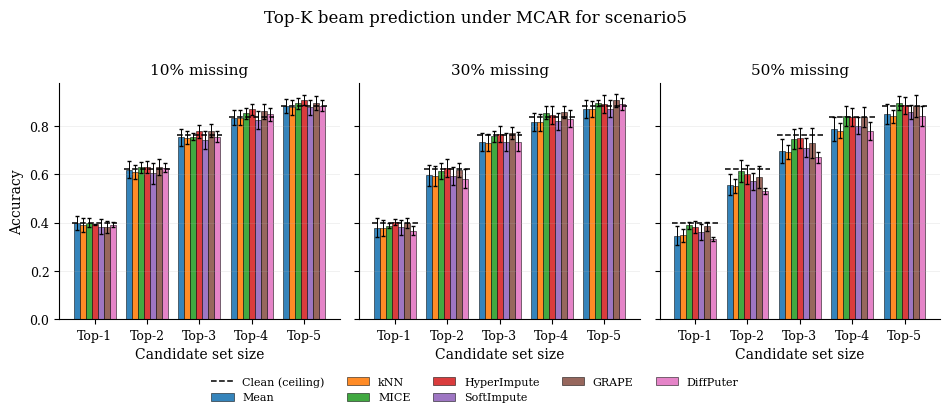

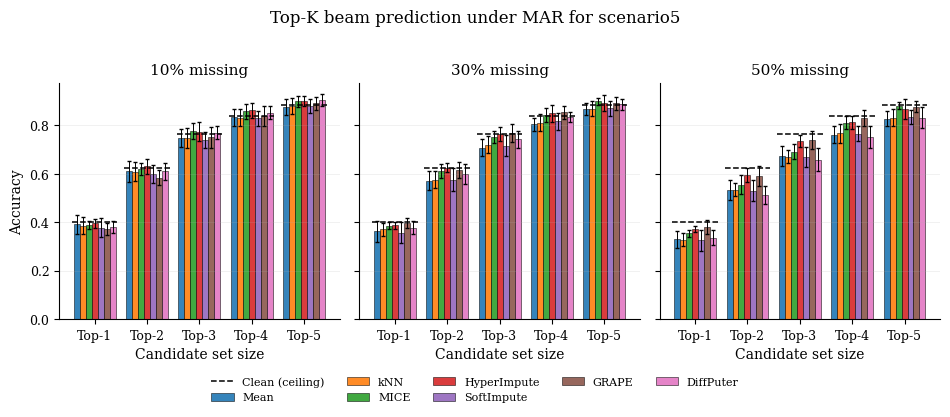

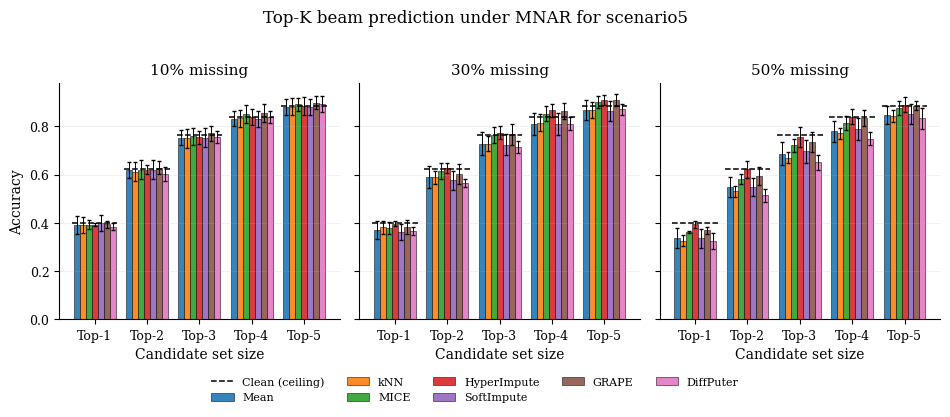

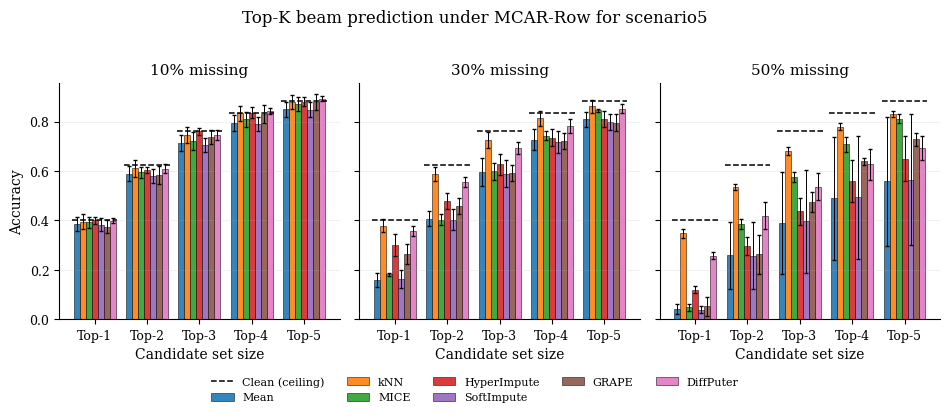

In [21]:
"""Downstream Top-K plots."""
import matplotlib.pyplot as plt
from common.visualization import METHOD_COLORS

LABEL_TO_DISPLAY = {
    "clean": "Clean", "mean": "Mean", "knn": "kNN", "mice": "MICE",
    "softimpute": "SoftImpute", "hyperimpute": "HyperImpute",
    "grape": "GRAPE", "diffputer": "DiffPuter",
}
IMPUTER_METHODS = ["Mean", "kNN", "MICE", "HyperImpute",
                   "SoftImpute", "GRAPE", "DiffPuter"]


def _as_plot_df(data):
    df = data if isinstance(data, pd.DataFrame) else pd.read_csv(data)
    df = df.copy()
    df["method"] = df["method"].map(lambda m: LABEL_TO_DISPLAY.get(m, m))
    if "scenario" not in df.columns and "mechanism" in df.columns:
        df["scenario"] = df["mechanism"]
    return df


def _present_imputers(sub):
    present = set(sub["method"].unique())
    return [m for m in IMPUTER_METHODS if m in present]


def _draw_topk_panel(ax, sub, methods, show_ylabel, show_legend):
    ks = [1, 2, 3, 4, 5]
    metrics = [f"top{k}_acc" for k in ks]
    bar_width = 0.8 / max(len(methods), 1)
    group_centers = np.arange(len(ks))

    for i, m in enumerate(methods):
        msub = sub[sub["method"] == m]
        means = [msub[met].mean() for met in metrics]
        stds = []
        for met in metrics:
            std_col = f"{met}_std"
            stds.append(msub[std_col].mean() if std_col in msub else msub[met].std())
        offsets = group_centers - 0.4 + (i + 0.5) * bar_width
        ax.bar(offsets, means, width=bar_width, yerr=stds, label=m,
               color=METHOD_COLORS.get(m), edgecolor="black", linewidth=0.4,
               error_kw=dict(elinewidth=0.7, capsize=1.5, ecolor="black"), alpha=0.9)

    clean = sub[sub["method"] == "Clean"]
    if not clean.empty:
        tick_half = bar_width * len(methods) / 2 + bar_width * 0.3
        for j, met in enumerate(metrics):
            ax.hlines(clean[met].mean(),
                      group_centers[j] - tick_half, group_centers[j] + tick_half,
                      color="black", linestyle="--", linewidth=1.1,
                      label="Clean (ceiling)" if j == 0 else None, zorder=10)

    ax.set_xticks(group_centers)
    ax.set_xticklabels([f"Top-{k}" for k in ks])
    ax.set_xlabel("Candidate set size")
    if show_ylabel:
        ax.set_ylabel("Accuracy")
    ax.grid(axis="y", alpha=0.25, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if show_legend:
        ax.legend(loc="lower right", ncol=2, fontsize=8, frameon=False)


def plot_topk_comparison_grid(data, scenario="MAR", proportions=None,
                              filename=None, methods=None):
    df = _as_plot_df(data)
    sc = df[df["scenario"] == scenario]
    if sc.empty:
        print(f"[plot] no rows for scenario={scenario}; skipping.")
        return
    proportions = proportions or sorted(sc["proportion"].unique())
    methods = methods or _present_imputers(sc)

    fig, axes = plt.subplots(1, len(proportions),
                             figsize=(3.2 * len(proportions), 3.6), sharey=True)
    if len(proportions) == 1 and not hasattr(axes, "__iter__"):
        axes = [axes]

    for ax_i, (ax, p) in enumerate(zip(axes, proportions)):
        sub = sc[sc["proportion"] == p]
        _draw_topk_panel(ax, sub, methods, show_ylabel=(ax_i == 0), show_legend=False)
        ax.set_title(f"{int(p*100)}% missing")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 5),
               bbox_to_anchor=(0.5, -0.10), frameon=False)
    fig.suptitle(f"Top-K beam prediction under {scenario} for {spec.name}", y=1.02)
    fig.tight_layout()
    if filename is not None:
        fig.savefig(filename, bbox_inches="tight")
    plt.show()


for mech in ["MCAR", "MAR", "MNAR", "MCAR-Row"]:
    plot_topk_comparison_grid(results, scenario=mech,
                              filename=FIGURES_DIR / f"{spec.name}_sq3_topk_grid_{mech}.png")

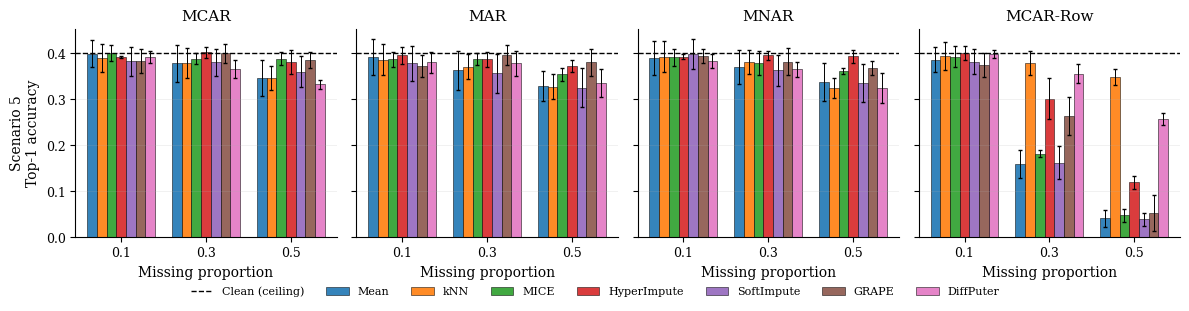

In [22]:
# ---------------------------------------------------------------------------
# RQ3 main-text figure: Top-1 beam-prediction accuracy.
# Rows = scenarios (Scenario 5 top, Scenario 33 bottom); columns = mechanisms;
# x-axis = missing proportion; one bar per imputer; dashed line = clean ceiling.
# Reads both scenarios' downstream result CSVs from disk, so it works even while
# some GRAPE cells are still being filled in (missing bars are simply blank).
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
from common.visualization import METHOD_COLORS

MECHS              = ["MCAR", "MAR", "MNAR", "MCAR-Row"]
METRIC, METRIC_STD = "top1_acc", "top1_acc_std"
LABEL_TO_DISPLAY   = {
    "clean": "Clean", "mean": "Mean", "knn": "kNN", "mice": "MICE",
    "softimpute": "SoftImpute", "hyperimpute": "HyperImpute",
    "grape": "GRAPE", "diffputer": "DiffPuter",
}
IMPUTER_ORDER = ["Mean", "kNN", "MICE", "HyperImpute",
                 "SoftImpute", "GRAPE", "DiffPuter"]


def _resolve_downstream_csv(stem):
    for name in (f"{stem}_downstream_full_results.csv",
                 f"{stem}_downstream_full_results_new.csv"):
        if (CSV_DIR / name).exists():
            return CSV_DIR / name
    return CSV_DIR / f"{stem}_downstream_full_results.csv"


SC_FILES = [("Scenario 5",  _resolve_downstream_csv("scenario5"))]


def _load_downstream(path):
    d = pd.read_csv(path)
    d["method"] = d["method"].map(lambda m: LABEL_TO_DISPLAY.get(m, m))
    return d


loaded = []
for name, path in SC_FILES:
    if path.exists():
        loaded.append((name, _load_downstream(path)))
    else:
        print(f"[skip] {name}: {path.name} not found")

proportions = sorted({p for _, d in loaded for p in d["proportion"].unique()})
present     = set().union(*[set(d["method"]) for _, d in loaded]) if loaded else set()
methods     = [m for m in IMPUTER_ORDER if m in present]

nrows, ncols = len(loaded), len(MECHS)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 3.0 * nrows),
                         sharey=True, squeeze=False)
bar_width = 0.8 / max(len(methods), 1)
centers   = np.arange(len(proportions))

for r, (sc_name, df) in enumerate(loaded):
    for c, mech in enumerate(MECHS):
        ax  = axes[r][c]
        sub = df[df["mechanism"] == mech]
        for i, m in enumerate(methods):
            ms = (sub[sub["method"] == m]
                  .set_index("proportion").reindex(proportions))
            offsets = centers - 0.4 + (i + 0.5) * bar_width
            ax.bar(offsets, ms[METRIC], width=bar_width, yerr=ms[METRIC_STD],
                   label=m, color=METHOD_COLORS.get(m),
                   edgecolor="black", linewidth=0.4,
                   error_kw=dict(elinewidth=0.7, capsize=1.5, ecolor="black"),
                   alpha=0.9)
        clean = sub[sub["method"] == "Clean"]
        if not clean.empty:
            ax.axhline(clean[METRIC].mean(), color="black", linestyle="--",
                       linewidth=1.0, zorder=10,
                       label="Clean (ceiling)" if (r == 0 and c == 0) else None)
        if r == 0:
            ax.set_title(mech)
        if c == 0:
            ax.set_ylabel(f"{sc_name}\nTop-1 accuracy")
        if r == nrows - 1:
            ax.set_xlabel("Missing proportion")
        ax.set_xticks(centers)
        ax.set_xticklabels([str(p) for p in proportions])
        ax.grid(axis="y", alpha=0.25, linewidth=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(methods) + 1,
            bbox_to_anchor=(0.5, -0.04), frameon=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "downstream_top1_grid.png", bbox_inches="tight")
plt.show()
